In [1]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import ast
import os

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

# Run Grid Search on Training set

We want to find the best performing parameters on the training set.

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 8

In [3]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=False)
    
    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]:
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [4]:
if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.4.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.parquet",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search",
      0.1,
      'v3.4.0',
      'v3.4.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/MTBC-CRyPTICv1.1.1-2025.8_grid_results_.csv')

else: 
   
   df = pd.read_csv('results/grid_search/MTBC-CRyPTICv1.1.1-2025.8_grid_results_.csv')

df

OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/bdq/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILEOUTFILE  catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/bdq/bg_0.15_p_0.95_FRS_0.1.csvcatalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cip/bg_0.15_p_0.95_FRS_0.1.csv

OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cip/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cap/bg_0.15_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cap/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/ami/bg_0.15_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/ami/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cip/bg_0.2_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cip/bg_0.05_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/bdq/bg_0.05_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv1.1.1-

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,AMI,0.05,0.90,0.874486,0.982756,0.921091,0.851703,0.984194
1,AMI,0.05,0.95,0.874140,0.982999,0.920675,0.849031,0.984420
2,AMI,0.10,0.90,0.854447,0.983671,0.957006,0.847027,0.984420
3,AMI,0.10,0.95,0.864939,0.983330,0.938112,0.847027,0.984420
4,AMI,0.15,0.90,0.853378,0.984449,0.960650,0.843687,0.985097
...,...,...,...,...,...,...,...,...
155,STM,0.15,0.95,0.953638,0.935429,0.905285,0.882897,0.942157
156,STM,0.20,0.90,0.953638,0.935815,0.908971,0.882897,0.942157
157,STM,0.20,0.95,0.953023,0.941029,0.900695,0.870790,0.947240
158,STM,0.25,0.90,0.952853,0.942364,0.900556,0.867488,0.948358


In [5]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)
melted_df

,DRUG,BACKGROUND_RATE,p_value,Metric,value
0,AMI,0.05,0.90,SENSITIVITY,87.448560
1,AMI,0.05,0.95,SENSITIVITY,87.414030
2,AMI,0.10,0.90,SENSITIVITY,85.444744
3,AMI,0.10,0.95,SENSITIVITY,86.493861
4,AMI,0.15,0.90,SENSITIVITY,85.337838
...,...,...,...,...,...
475,STM,0.15,0.95,DPR,90.528512
476,STM,0.20,0.90,DPR,90.897079
477,STM,0.20,0.95,DPR,90.069541
478,STM,0.25,0.90,DPR,90.055633


Note: DLM has been run with dprE1 as an additional gene (its DLM's target but isn't a WHO candidate gene) - couple of RAVs, which improve sensitivity

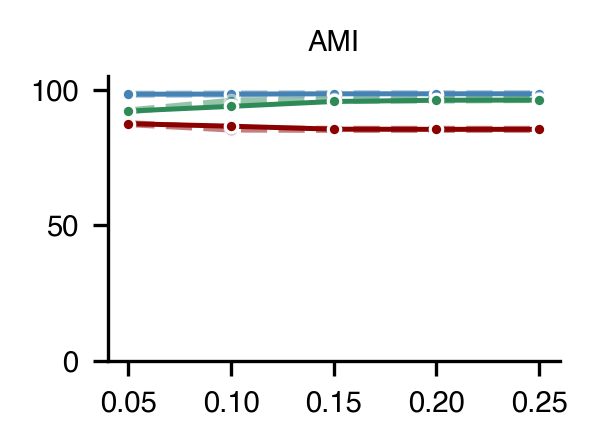

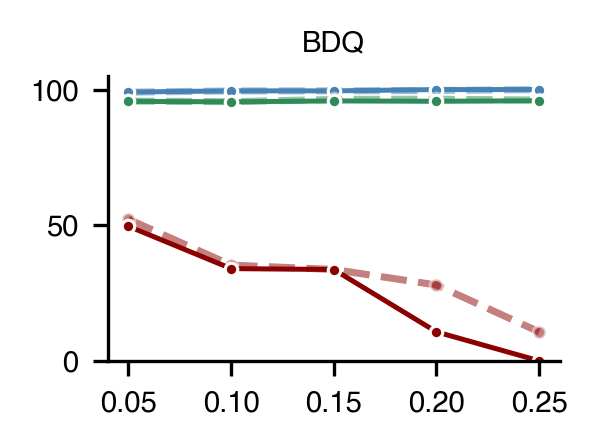

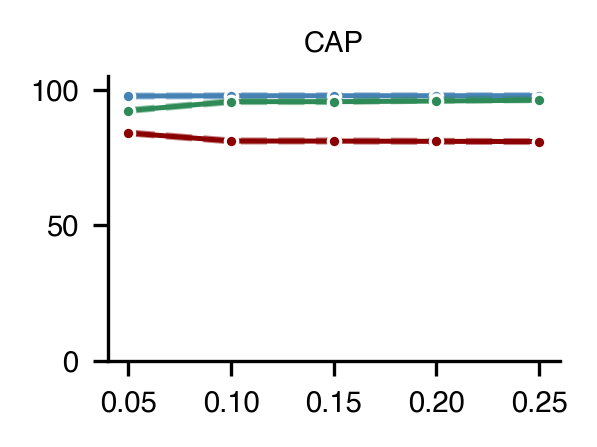

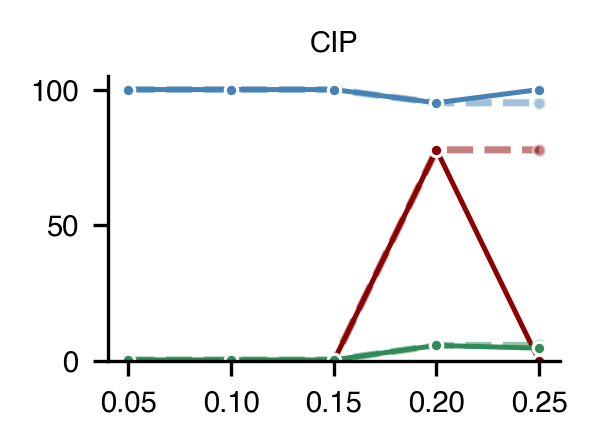

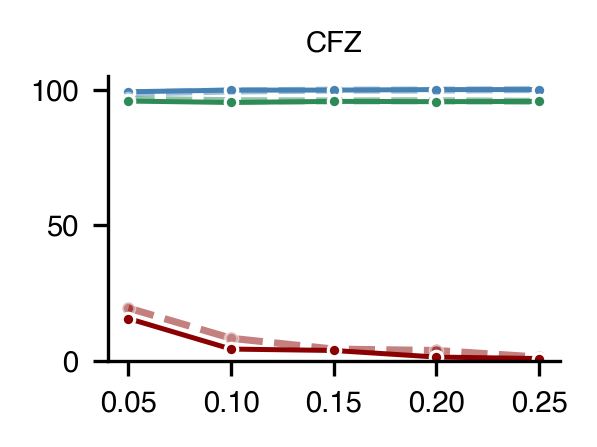

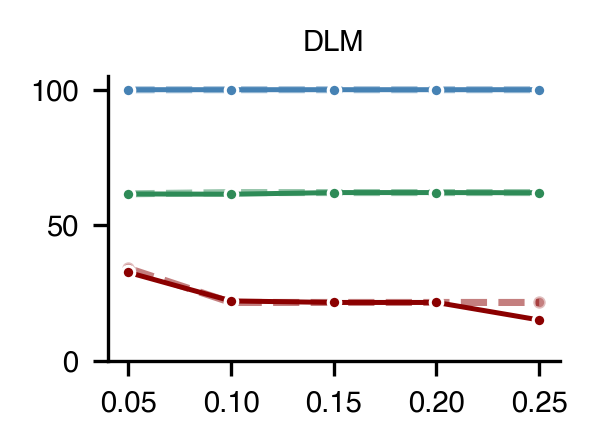

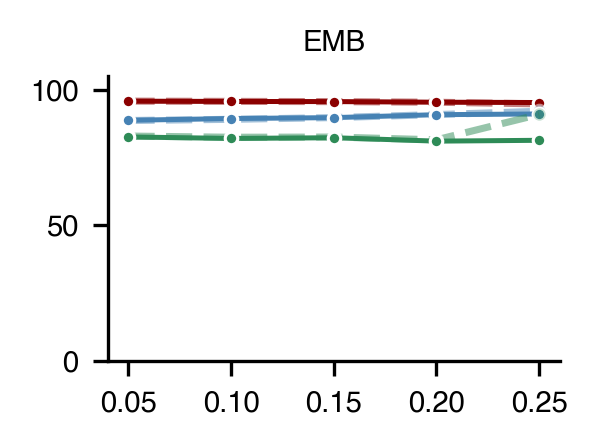

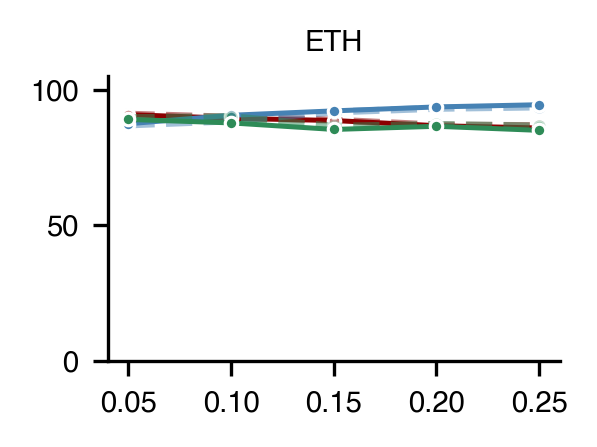

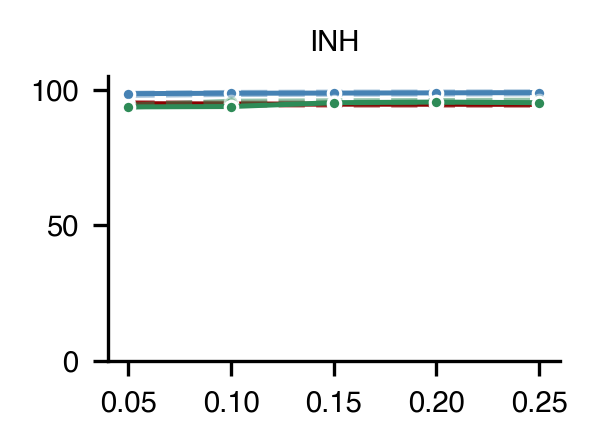

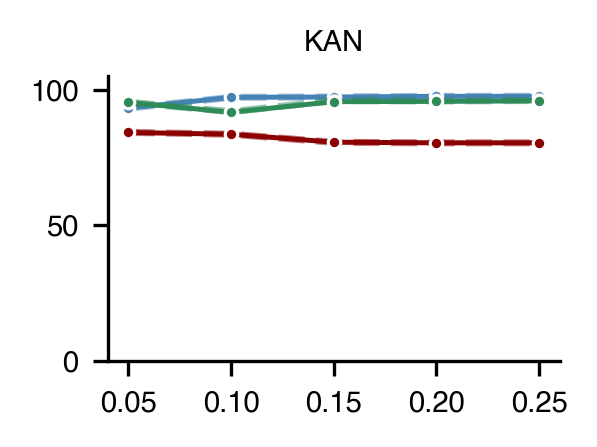

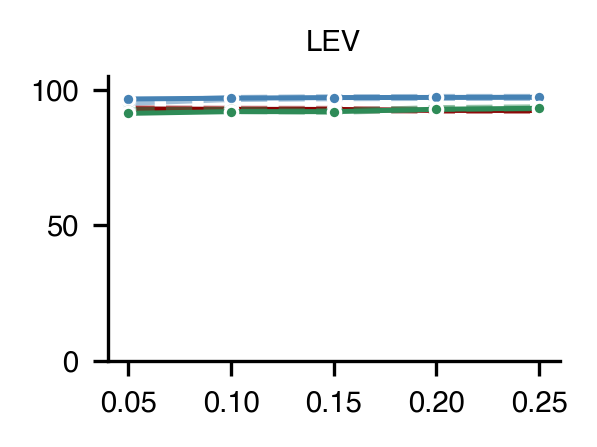

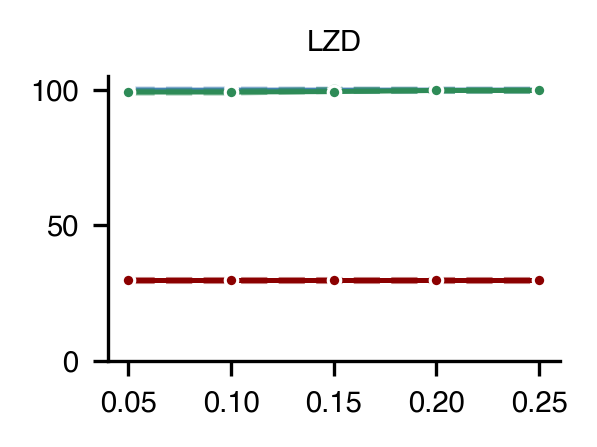

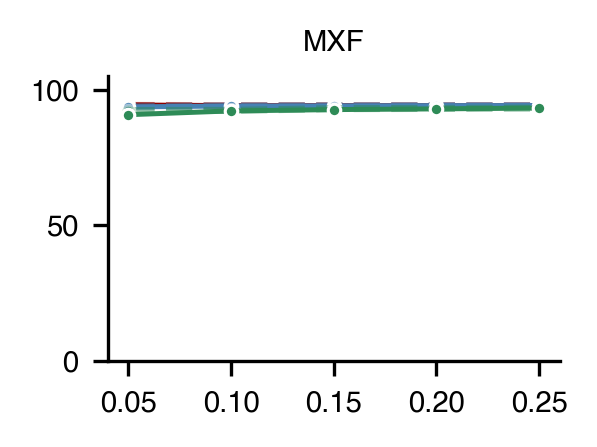

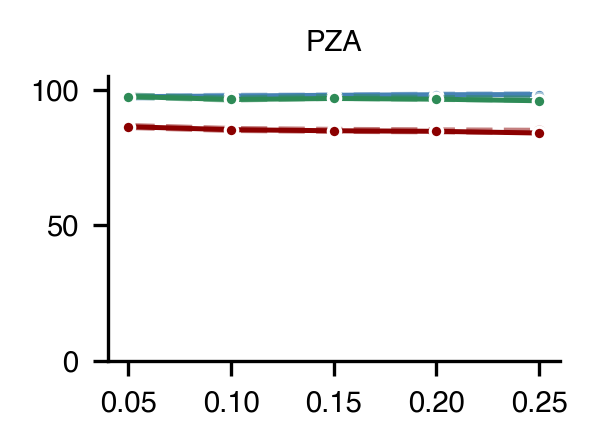

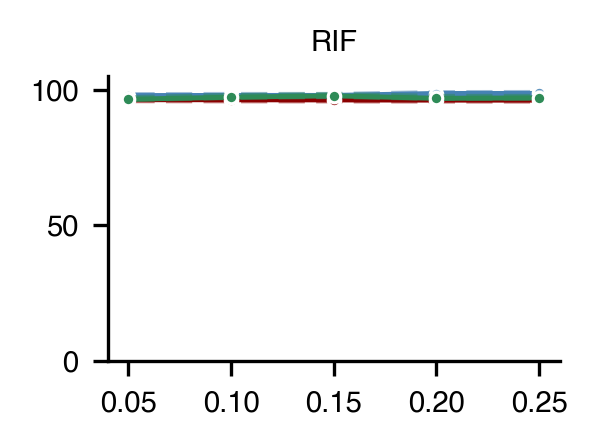

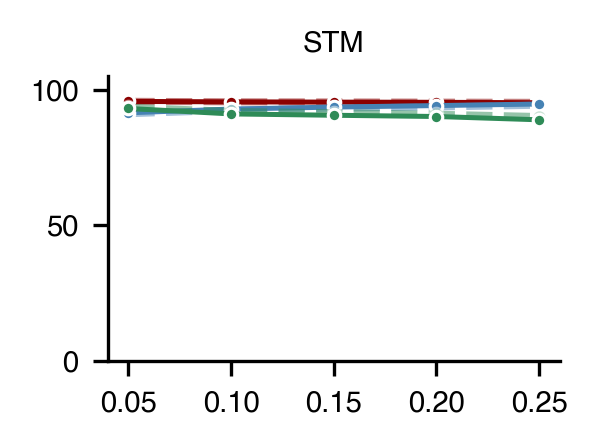

In [6]:
graphs.grid_search_plots(melted_df)

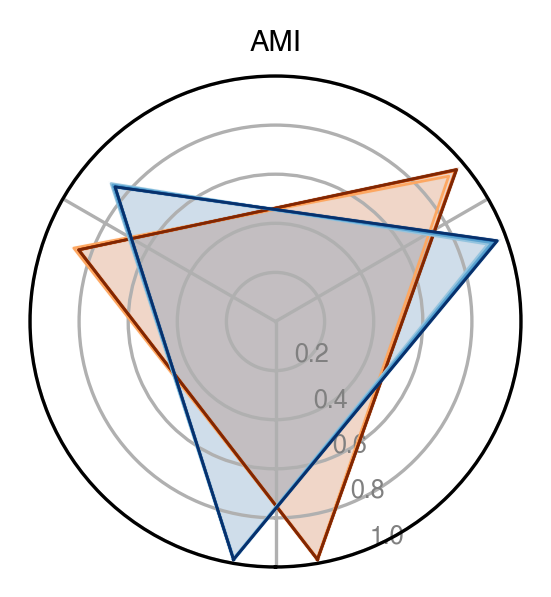

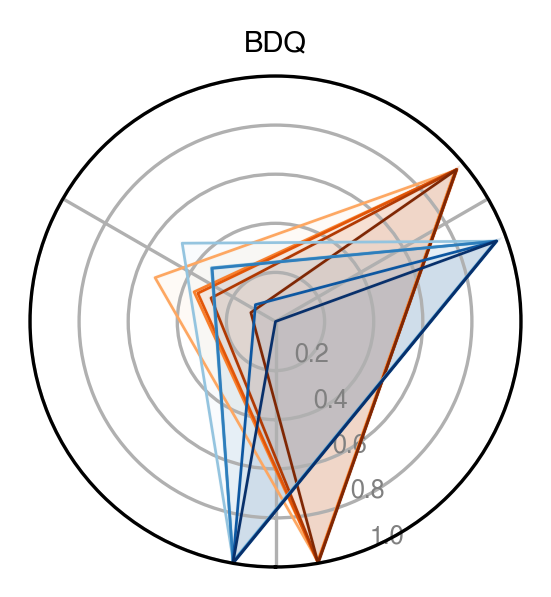

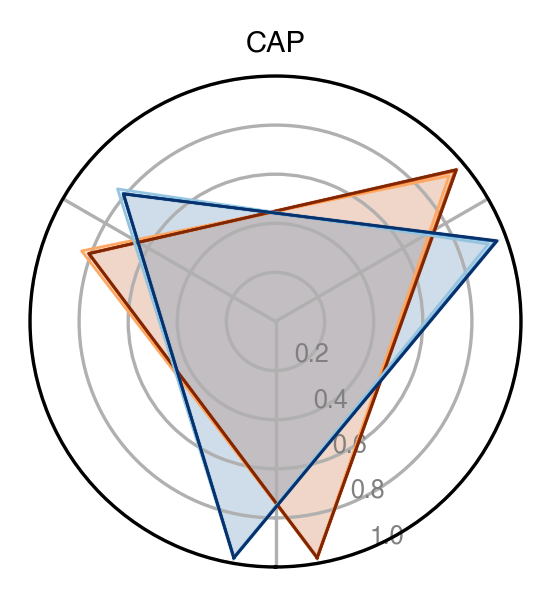

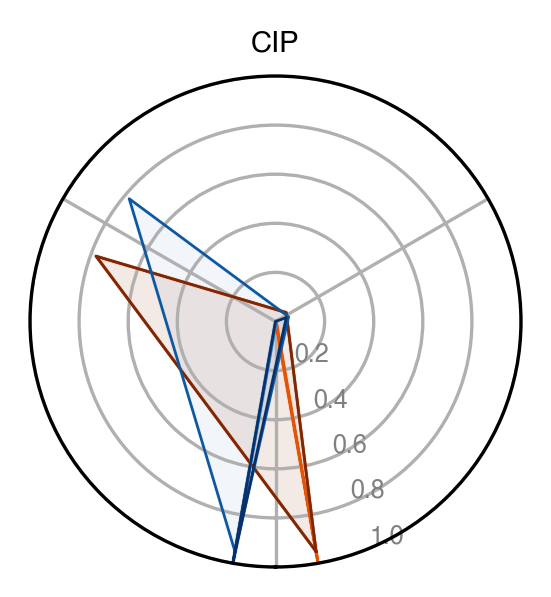

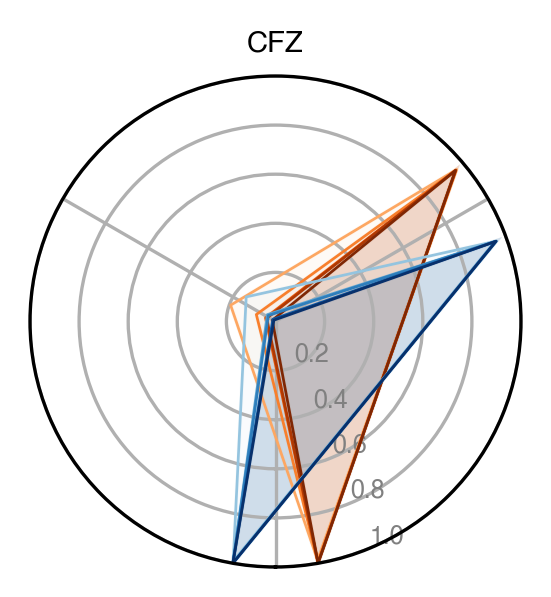

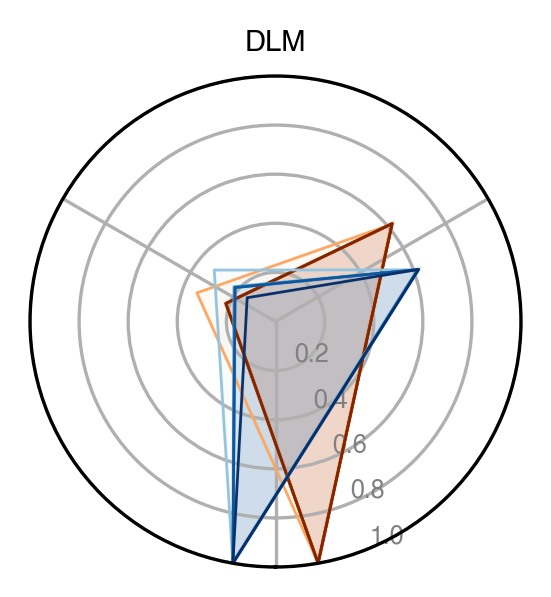

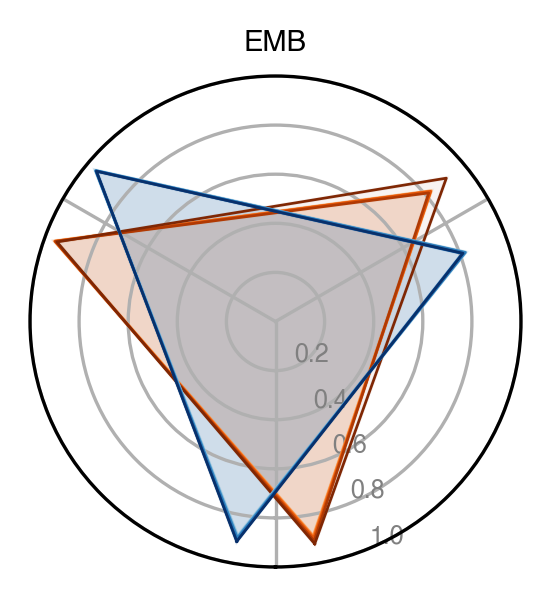

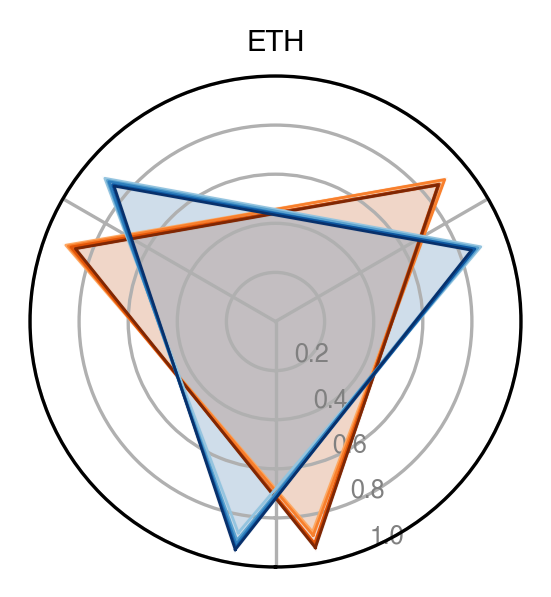

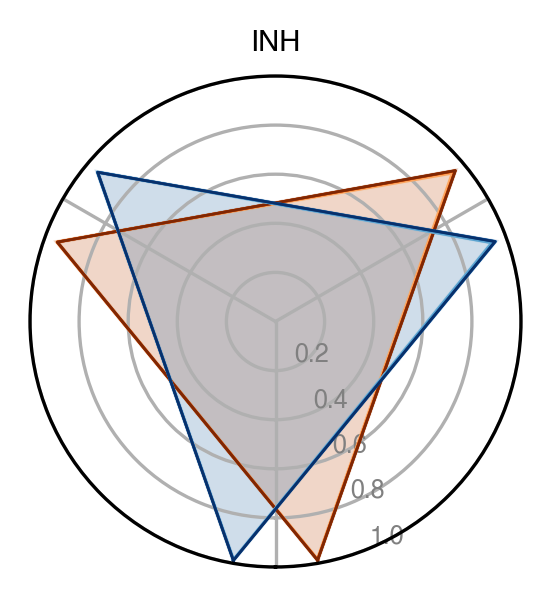

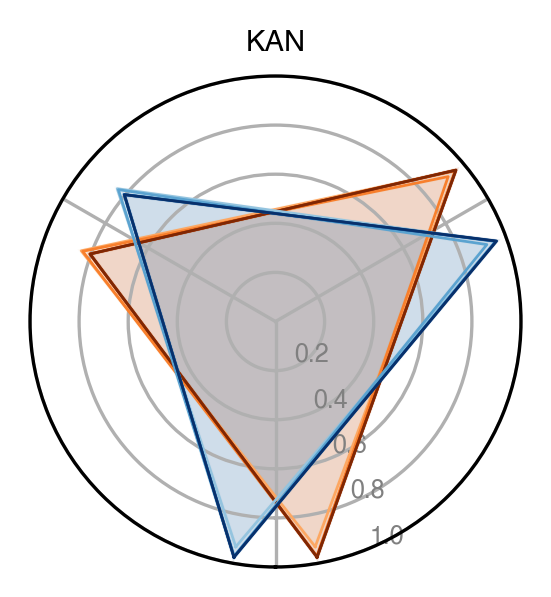

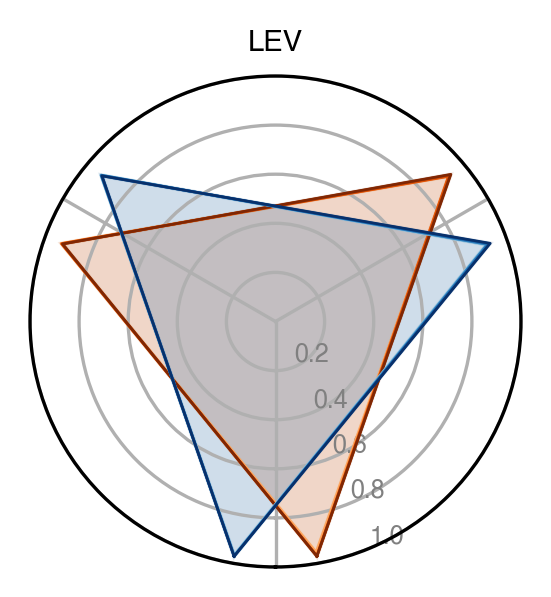

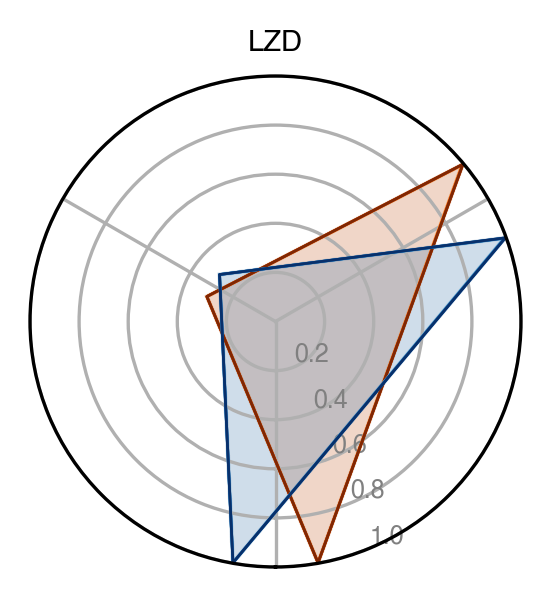

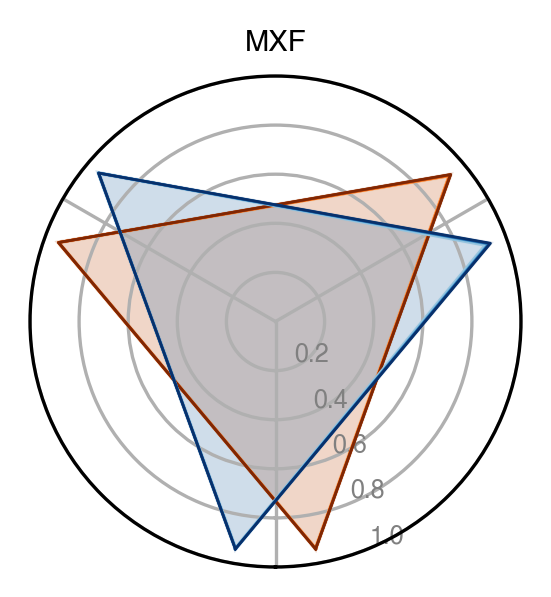

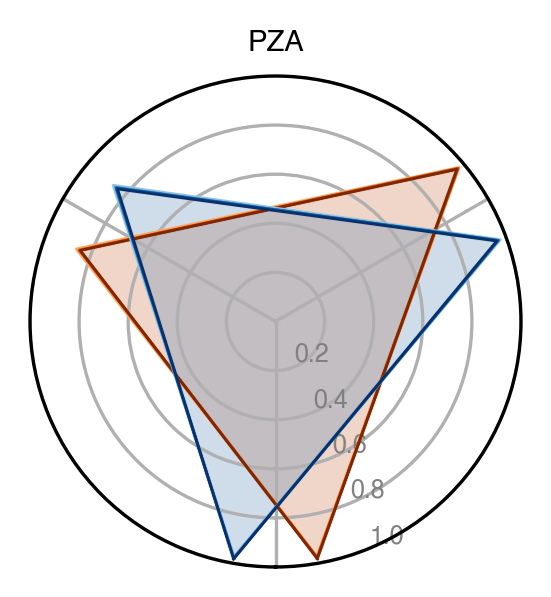

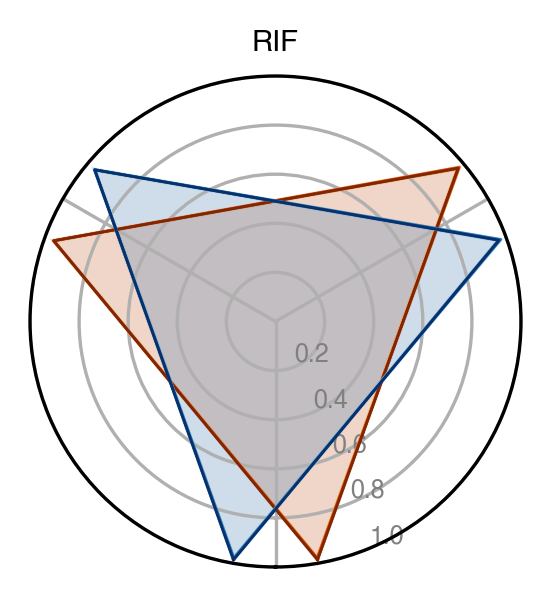

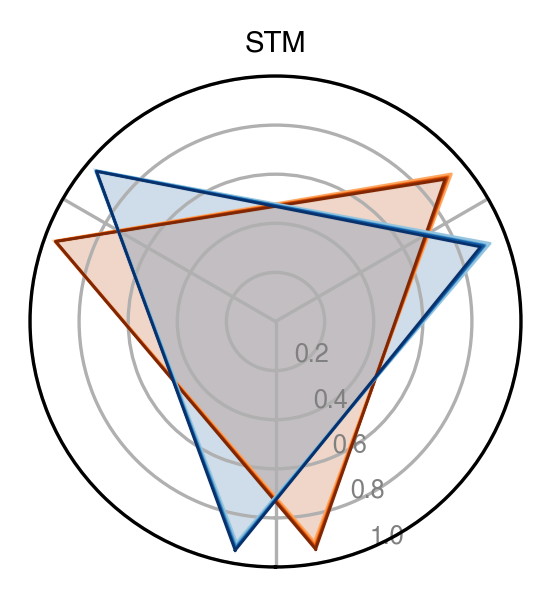

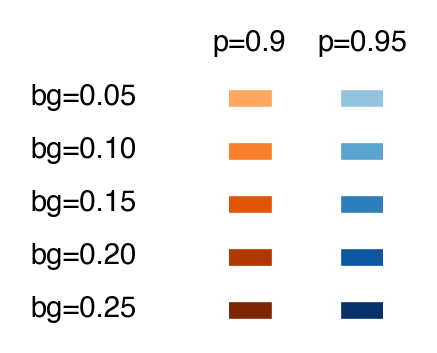

In [7]:
#same results, different plot
graphs.grid_search_radars(df)

# Use weighted score to choose best performing catalogue

In [8]:
#determine the best performing catalogue
opt_cats = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

cat_counts = []

#display performance and label counts
for i in opt_cats.index:
    drug = opt_cats['DRUG'][i]
    rate = opt_cats['BACKGROUND_RATE'][i]
    pval = opt_cats['p_value'][i]

    path = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/{drug.lower()}/bg_{rate}_p_{pval}_FRS_0.1.csv"
    cat = pd.read_csv(path)

    # Filter out rows with '*' in MUTATION
    cat = cat[cat['EVIDENCE'].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})]

    # Skip if empty after filtering
    if cat.empty:
        continue

    cat_counts.append({
        "DRUG": drug,
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    })

# Convert to DataFrame
cat_counts = pd.DataFrame(cat_counts)

# Merge and save
opt_cats = pd.merge(opt_cats, cat_counts, on='DRUG')
opt_cats['catalogue'] = 'MTBC-CRyPTICv1.1.1-2025.8'
#opt_cats.loc[:, 'p_value'] = 1 - opt_cats.p_value.values
opt_cats.to_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', index=False)

# Display result
opt_cats


,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.20,0.90,0.961417,0.985268,0.971120,0.943997,0.985760,0.970513,42,16,352,410,MTBC-CRyPTICv1.1.1-2025.8
1,INH,0.25,0.90,0.945534,0.987895,0.956970,0.917435,0.988510,0.960530,62,23,626,711,MTBC-CRyPTICv1.1.1-2025.8
2,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,8,542,665,MTBC-CRyPTICv1.1.1-2025.8
3,LEV,0.25,0.90,0.923222,0.971103,0.932654,0.894161,0.973286,0.939473,13,19,330,362,MTBC-CRyPTICv1.1.1-2025.8
4,MXF,0.25,0.95,0.940669,0.941006,0.931879,0.914180,0.945520,0.939012,11,22,489,522,MTBC-CRyPTICv1.1.1-2025.8
5,EMB,0.25,0.90,0.947307,0.919858,0.908448,0.875294,0.927433,0.931300,20,58,1056,1134,MTBC-CRyPTICv1.1.1-2025.8
6,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,0,143,583,MTBC-CRyPTICv1.1.1-2025.8
7,AMI,0.05,0.90,0.874486,0.982756,0.921091,0.851703,0.984194,0.916288,11,6,383,400,MTBC-CRyPTICv1.1.1-2025.8
8,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,2,234,279,MTBC-CRyPTICv1.1.1-2025.8
9,ETH,0.05,0.90,0.908987,0.869838,0.896154,0.823346,0.883667,0.894676,298,0,325,623,MTBC-CRyPTICv1.1.1-2025.8


In [9]:
print('Total number of non-U rows:', opt_cats[['R', 'S']].to_numpy().sum())

Total number of non-U rows: 1332


In [10]:
cat_counts = []

for i in opt_cats.index:
    drug = opt_cats.loc[i, 'DRUG']
    rate = opt_cats.loc[i, 'BACKGROUND_RATE']
    pval = opt_cats.loc[i, 'p_value']

    path = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/{drug.lower()}/bg_{rate}_p_{pval}_FRS_0.1.csv"
    if not os.path.exists(path):
        continue  # Skip if file doesn't exist

    cat = pd.read_csv(path)

    # Extract gene name from mutations first, for default-including set
    cat['GENE'] = cat['MUTATION'].apply(lambda x: x.split('@')[0])
    all_genes = cat['GENE'].unique()

    # Filter out default rules
    cat_filtered = cat[cat['EVIDENCE'].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})]

    # Ensure every gene gets a row, even if not in filtered set
    for gene in all_genes:
        group = cat_filtered[cat_filtered['GENE'] == gene]
        if group.empty:
            cat_counts.append({
                "DRUG": drug,
                "GENE": gene,
                "R": 0,
                "S": 0,
                "U": 0,
                "Total": 0,
                "BACKGROUND_RATE": rate,
                "p_value": pval
            })
        else:
            cat_counts.append({
                "DRUG": drug,
                "GENE": gene,
                "R": group["PREDICTION"].value_counts().get("R", 0),
                "S": group["PREDICTION"].value_counts().get("S", 0),
                "U": group["PREDICTION"].value_counts().get("U", 0),
                "Total": len(group),
                "BACKGROUND_RATE": rate,
                "p_value": pval
            })

# Create DataFrame from counts
cat_counts = pd.DataFrame(cat_counts)

# Add catalogue label
cat_counts['catalogue'] = 'MTBC-CRyPTICv1.1.1-2025.8'

# Save to CSV
cat_counts.to_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8_by_gene.csv', index=False)


# Display final DataFrame
cat_counts



,DRUG,GENE,R,S,U,Total,BACKGROUND_RATE,p_value,catalogue
0,RIF,rpoB,42,16,352,410,0.20,0.90,MTBC-CRyPTICv1.1.1-2025.8
1,INH,katG,50,7,426,483,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
2,INH,fabG1,5,4,52,61,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
3,INH,ahpC,3,7,96,106,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
4,INH,inhA,4,5,52,61,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
5,STM,gid,102,5,369,476,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
6,STM,rrs,8,3,153,164,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
7,STM,rpsL,5,0,20,25,0.15,0.90,MTBC-CRyPTICv1.1.1-2025.8
8,LEV,gyrA,10,13,187,210,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8
9,LEV,gyrB,3,6,143,152,0.25,0.90,MTBC-CRyPTICv1.1.1-2025.8


# Create catalogue with all drugs 

In [11]:


rows = []

for idx,row in opt_cats.iterrows():
    cat_path = pathlib.Path( "./catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{np.round(row.p_value, 2)}_FRS_0.1.csv"
    print (cat)
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'MTBC-CRyPTICv1.1.1-2025.8'
cat.CATALOGUE_VERSION = '1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv',index=False)
cat


catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/rif/bg_0.2_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/inh/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/stm/bg_0.15_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/lev/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/mxf/bg_0.25_p_0.95_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/emb/bg_0.25_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/pza/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/ami/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cap/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/eth/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/kan/bg_0.1_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/bdq/bg_0.05_p_0.9_FRS_0.1.csv
catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search/cip/

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.008733624454148471, ""confiden...",{}
1,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0485...",{}
2,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1446...",{}
3,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
4,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [-3.28060001...",{}
...,...,...,...,...,...,...,...,...,...,...,...
244,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
245,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
246,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
247,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}


# Additional analysis

### PZA catalogue counts

Why does pyrazinamide have so many Rs and only 1 S?

In [12]:
cat[cat.DRUG == 'PZA'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()


np.int64(212)

In [13]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_72198/2756042707.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,U
mut_type,,
indel,185,25
point,255,119


In [14]:
cat

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.008733624454148471, ""confiden...",{}
1,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0485...",{}
2,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1446...",{}
3,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
4,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [-3.28060001...",{}
...,...,...,...,...,...,...,...,...,...,...,...
244,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
245,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
246,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
247,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}


### ETH catalogue counts

In [15]:
cat[cat.DRUG == 'ETH'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()


np.int64(198)

In [16]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'ETH') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_72198/4234506190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,U
mut_type,,
indel,123,69
point,175,258


In [17]:
cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.apply(lambda x: 'ins' in x or 'del' in x))]


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@*=,S,{},"{""default_rule"": ""True""}",{}
2,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@H57D,R,{},"{""proportion"": 0.9783549783549783, ""confidence...",{}
3,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@V180F,R,{},"{""proportion"": 1.0, ""confidence"": [0.802594952...",{}
4,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@W68R,R,{},"{""proportion"": 0.9230769230769231, ""confidence...",{}
6,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@L182S,R,{},"{""proportion"": 0.6, ""confidence"": [0.392606369...",{}
...,...,...,...,...,...,...,...,...,...,...,...
581,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@A143S,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
582,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@T167P,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
583,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@Q122E,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
586,NC00962.3,MTBC-CRyPTICv1.1.1-2025.8,1,GARC1,RUS,PZA,pncA@-*?,U,{},"{""default_rule"": ""True""}",{}
